# KL-Divergence

Instead of comparing likelihoods, I'd like to compare KL-Divergences. The KL-Divergence $D_{KL}(P || Q)$ is a statistical distance and measures how far an approximate distribution $Q$ is away from true distribution $P$ on some data $X$.

In our plot, we'll compute KL-Divergence (and reverse KL) between base model distribution $P$ and trained model $Q^{T}_{k}$ on data $X^{k}_i$. The $X^{k}_{i}$ will come from the checkpoint $i$ of method $k$. The superscript $T$ in $Q^{T}_k$ denotes the last checkpoint $T$ of the model trained with method $k$.

We'll approximate the true KL-Divergence, as we do not have access to the full probability distribution, but only the log-likelihood of the sampled tokens. 

In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt

In [2]:
root = "/ptmp/rfechner/out/exp09"
paths = [
    os.path.join(root, p, 'val_jsonl') for p in os.listdir(root)
]
paths

['/ptmp/rfechner/out/exp09/qwen2.5_7b__grpo-s/val_jsonl',
 '/ptmp/rfechner/out/exp09/qwen2.5_7b__grpo/val_jsonl',
 '/ptmp/rfechner/out/exp09/qwen2.5_7b__kl-cov/val_jsonl',
 '/ptmp/rfechner/out/exp09/qwen2.5_7b__dapo/val_jsonl']

In [20]:
import os
import numpy as np
import pandas as pd

def compute_kl(log_p, log_q, eps=1e-12):
    """
    Compute KL(P || Q) where `log_p` and `log_q` are log-prob vectors.

    KL(P||Q) = sum_i exp(log_p[i]) * (log_p[i] - log_q[i])
    """
    # Clip to avoid log(0) or exp(-inf)
    log_p = np.maximum(log_p, np.log(eps))
    log_q = np.maximum(log_q, np.log(eps))

    p = np.exp(log_p)
    return np.sum(p * (log_p - log_q))

def gather_kl(path : str):
    checkpoint_results = []
    files = sorted(
        [x for x in os.listdir(path) if x.endswith("_precomp.jsonl")],
        key=lambda x: int(x.split("_")[0])
    )
    base_file, trained_file = [files[0], files[-1]]

    print("Processing only first and last checkpoints.")

    suffix_ks = np.arange(0, 11) / 10
    prefix_ks = np.arange(0, 11) / 10

    base_fp = os.path.join(path, base_file)
    trained_fp = os.path.join(path, trained_file)

    print(f"Processing:\n  Base:    {base_fp}\n  Trained: {trained_fp}")

    base_chunks = pd.read_json(base_fp, lines=True, chunksize=10000)
    trained_chunks = pd.read_json(trained_fp, lines=True, chunksize=10000)

    dfs = []

    for idx, (base_chunk, trained_chunk) in enumerate(zip(base_chunks, trained_chunks)):
        if idx % 10 == 0:
            print(f"Chunk {idx}")

        # Extract logprobs
        base_logs = base_chunk["logprobs"].to_numpy()
        trained_logs = trained_chunk["logprobs"].to_numpy()

        res = {
            "input_hash": base_chunk["input"].apply(hash).to_numpy(),
            "score": base_chunk["score"].to_numpy(),
            "checkpoint_global_step": base_chunk["checkpoint_global_step"].to_numpy(),
            "data_global_step": base_chunk["data_global_step"].to_numpy()
        }

        # ----- Prefix/suffix KLs -----
        for k in prefix_ks:
            name_f = f"prefix_{k}_kl_fwd"
            name_r = f"prefix_{k}_kl_rev"

            res[name_f] = np.array([
                compute_kl(p[:int(k * len(p))], q[:int(k * len(q))])
                if int(k * len(p)) > 0 else np.nan
                for p, q in zip(base_logs, trained_logs)
            ])

            res[name_r] = np.array([
                compute_kl(q[:int(k * len(q))], p[:int(k * len(p))])
                if int(k * len(p)) > 0 else np.nan
                for p, q in zip(base_logs, trained_logs)
            ])

        for k in suffix_ks:
            name_f = f"suffix_{k}_kl_fwd"
            name_r = f"suffix_{k}_kl_rev"

            res[name_f] = np.array([
                compute_kl(p[int(k * len(p)):], q[int(k * len(q)):])
                if int(k * len(p)) < len(p) else np.nan
                for p, q in zip(base_logs, trained_logs)
            ])

            res[name_r] = np.array([
                compute_kl(q[int(k * len(q)):], p[int(k * len(p)):])
                if int(k * len(p)) < len(p) else np.nan
                for p, q in zip(base_logs, trained_logs)
            ])

        dfs.append(pd.DataFrame(res))

        checkpoint_results.append(pd.concat(dfs, ignore_index=True))

    return checkpoint_results

In [21]:
RELOAD = True
import pickle
pltroot="/u/rfechner/verl/workspace/plots/.tmpfiles"
os.makedirs(pltroot, exist_ok=True)

if RELOAD:
    kls = {}
    for path in paths:
        print('Computing kl divs for path: ', path)
        method = path.split('/')[-2].split('__')[-1]
        kls[method] = gather_kl(path)

    with open(os.path.join(pltroot, 'exp09_gather_kls.pickle'), 'wb') as file:
        pickle.dump(obj=kls, file=file)
else:
    with open(os.path.join(pltroot, 'exp09_gather_kls.pickle'), 'rb') as file:
        kls = pickle.load(file=file)    

Computing kl divs for path:  /ptmp/rfechner/out/exp09/qwen2.5_7b__grpo-s/val_jsonl
Processing only first and last checkpoints.
Processing:
  Base:    /ptmp/rfechner/out/exp09/qwen2.5_7b__grpo-s/val_jsonl/0_precomp.jsonl
  Trained: /ptmp/rfechner/out/exp09/qwen2.5_7b__grpo-s/val_jsonl/70_precomp.jsonl
Chunk 0
Computing kl divs for path:  /ptmp/rfechner/out/exp09/qwen2.5_7b__grpo/val_jsonl
Processing only first and last checkpoints.
Processing:
  Base:    /ptmp/rfechner/out/exp09/qwen2.5_7b__grpo/val_jsonl/0_precomp.jsonl
  Trained: /ptmp/rfechner/out/exp09/qwen2.5_7b__grpo/val_jsonl/70_precomp.jsonl
Chunk 0
Computing kl divs for path:  /ptmp/rfechner/out/exp09/qwen2.5_7b__kl-cov/val_jsonl
Processing only first and last checkpoints.
Processing:
  Base:    /ptmp/rfechner/out/exp09/qwen2.5_7b__kl-cov/val_jsonl/0_precomp.jsonl
  Trained: /ptmp/rfechner/out/exp09/qwen2.5_7b__kl-cov/val_jsonl/60_precomp.jsonl
Chunk 0
Computing kl divs for path:  /ptmp/rfechner/out/exp09/qwen2.5_7b__dapo/val_j

In [22]:
kls = {k : pd.concat(vs, axis=0) for k, vs in kls.items()}

In [23]:
kls['grpo'].keys()

Index(['input_hash', 'score', 'checkpoint_global_step', 'data_global_step',
       'prefix_0.0_kl_fwd', 'prefix_0.0_kl_rev', 'prefix_0.1_kl_fwd',
       'prefix_0.1_kl_rev', 'prefix_0.2_kl_fwd', 'prefix_0.2_kl_rev',
       'prefix_0.3_kl_fwd', 'prefix_0.3_kl_rev', 'prefix_0.4_kl_fwd',
       'prefix_0.4_kl_rev', 'prefix_0.5_kl_fwd', 'prefix_0.5_kl_rev',
       'prefix_0.6_kl_fwd', 'prefix_0.6_kl_rev', 'prefix_0.7_kl_fwd',
       'prefix_0.7_kl_rev', 'prefix_0.8_kl_fwd', 'prefix_0.8_kl_rev',
       'prefix_0.9_kl_fwd', 'prefix_0.9_kl_rev', 'prefix_1.0_kl_fwd',
       'prefix_1.0_kl_rev', 'suffix_0.0_kl_fwd', 'suffix_0.0_kl_rev',
       'suffix_0.1_kl_fwd', 'suffix_0.1_kl_rev', 'suffix_0.2_kl_fwd',
       'suffix_0.2_kl_rev', 'suffix_0.3_kl_fwd', 'suffix_0.3_kl_rev',
       'suffix_0.4_kl_fwd', 'suffix_0.4_kl_rev', 'suffix_0.5_kl_fwd',
       'suffix_0.5_kl_rev', 'suffix_0.6_kl_fwd', 'suffix_0.6_kl_rev',
       'suffix_0.7_kl_fwd', 'suffix_0.7_kl_rev', 'suffix_0.8_kl_fwd',
       'suffix

In [24]:
import matplotlib.pyplot as plt
plotdir = os.path.join(pltroot, 'plots')
os.makedirs(plotdir, exist_ok=True)


# Enable LaTeX for all text
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "mathtext.fontset": "cm",
})

VAL_FREQ = 5
K_VALUES = np.arange(0, 11) / 10

def plot_kl_prefix_suffix(experiment_name : str, df : pd.DataFrame) -> None:
    cmap = plt.get_cmap('viridis', len(K_VALUES))

    # ---------- compute stats ----------
    def compute_stats(df, colname):
        values, stds = [], []
        groups = df.groupby("data_global_step", sort=True)
        for _, group in groups:
            arr = group[colname].to_numpy()
            values.append(np.nanmean(arr))
            stds.append(np.nanstd(arr))
        return values, stds

    # ---------- FIGURE ----------
    fig, (ax1, ax2) = plt.subplots(
        nrows=1, ncols=2, sharey=False, figsize=(12, 4)
    )

    # ==========================================================
    # ===================== SUFFIX PLOT =========================
    # ==========================================================
    
    for i, k in enumerate(K_VALUES):
        fwd, rev = f"suffix_{k}_kl_fwd", f"suffix_{k}_kl_rev"
        fwd_kls, _ = compute_stats(df, fwd)
        rev_kls, _ = compute_stats(df, rev)
        xs = np.arange(0, len(fwd_kls) * VAL_FREQ, VAL_FREQ)    
        color = cmap(i)
        ax1.plot(xs, fwd_kls, label=fr"$k={k}$ Forward KL", 
                    color=color)
        ax1.plot(xs, rev_kls, label=fr"$k={k}$ Reverse KL", 
                    color=color, linestyle="--")

    # ax1.plot(xs, compute_stats(df, 'kl_forward')[0], label='$k=0.0$ Forward KL')
    # ax1.plot(xs, compute_stats(df, 'kl_reverse')[0], label='$k=0.0$ Reverse KL')
    ax1.set_ylabel(r"\textbf{Divergence}", fontsize=11)
    ax1.set_xlabel(r"$x[k \cdot N:]$ \textbf{ source checkpoint training step}", fontsize=11)
    ax1.set_title(r"\textbf{Suffix KL-Divergences}", fontsize=13)

    # ==========================================================
    # ===================== PREFIX PLOT =========================
    # ==========================================================

    for i, k in enumerate(K_VALUES):
        fwd, rev = f"prefix_{k}_kl_fwd", f"prefix_{k}_kl_rev"
        fwd_kls, _ = compute_stats(df, fwd)
        rev_kls, _ = compute_stats(df, rev)
        xs = np.arange(0, len(fwd_kls) * VAL_FREQ, VAL_FREQ)    
        color = cmap(i)
        ax2.plot(xs, fwd_kls, label=fr"$k={k}$ Forward KL", 
                    color=color)
        ax2.plot(xs, rev_kls, label=fr"$k={k}$ Reverse KL", 
                    color=color, linestyle="--")

    # ax2.plot(xs, compute_stats(df, 'kl_forward')[0], label='$k=1.0$ Forward KL')
    # ax2.plot(xs, compute_stats(df, 'kl_reverse')[0], label='$k=1.0$ Reverse KL')
    ax2.set_ylabel(r"\textbf{Divergence}", fontsize=11)
    ax2.set_xlabel(r"$x[k \cdot N:]$ \textbf{ source checkpoint training step}", fontsize=11)
    ax2.set_title(r"\textbf{Prefix KL-Divergences}", fontsize=13)


    # ---------- Title ----------
    model, method = experiment_name.split("__")
    plt.suptitle(
        rf"KL-Divergences, Normalized by Sequence Length; \quad \textbf{{Model:}} {model} \qquad \textbf{{Method:}} {method}",
        fontsize=14
    )

    # ---------- Legend ----------
    plt.legend(bbox_to_anchor=(1.05, 1.0), loc="upper left", fontsize=9)
    plt.savefig(os.path.join(plotdir, f"{experiment_name}_kl_plot.pdf"), dpi=300, bbox_inches="tight")
    plt.tight_layout()
    plt.show()

/tmp/ipykernel_64949/3000860665.py:26: RuntimeWarning: Mean of empty slice
  values.append(np.nanmean(arr))
/u/rfechner/conda-envs/notebooks/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


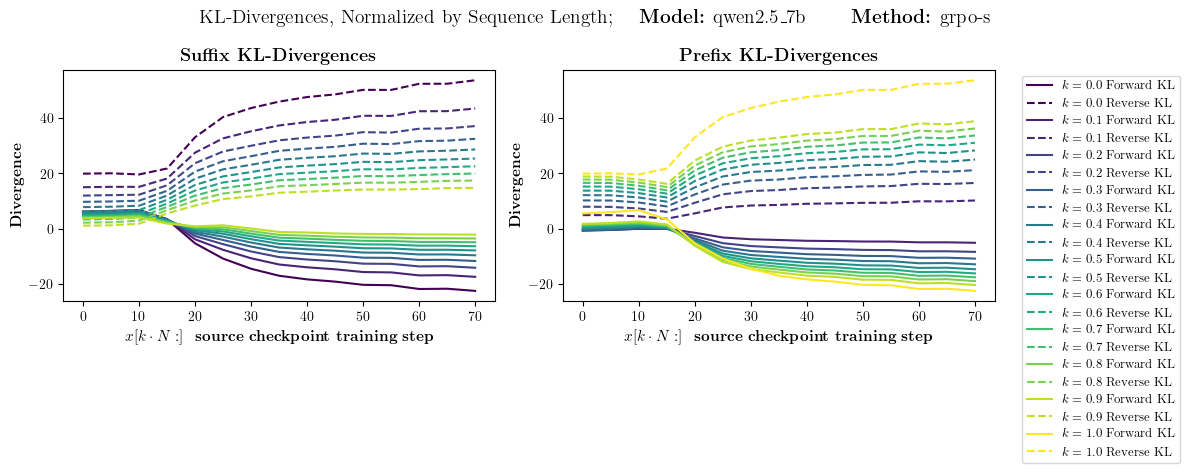

/tmp/ipykernel_64949/3000860665.py:26: RuntimeWarning: Mean of empty slice
  values.append(np.nanmean(arr))
/u/rfechner/conda-envs/notebooks/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


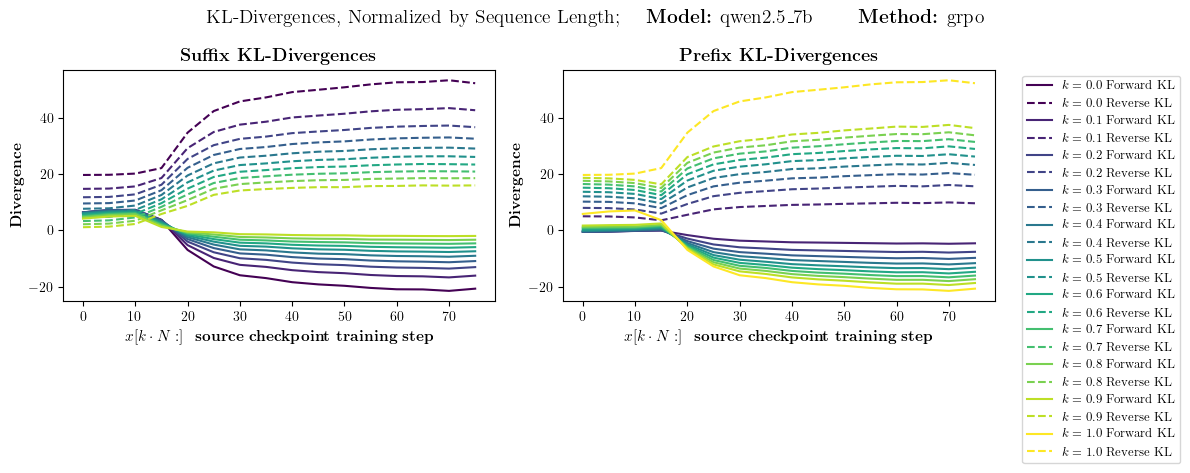

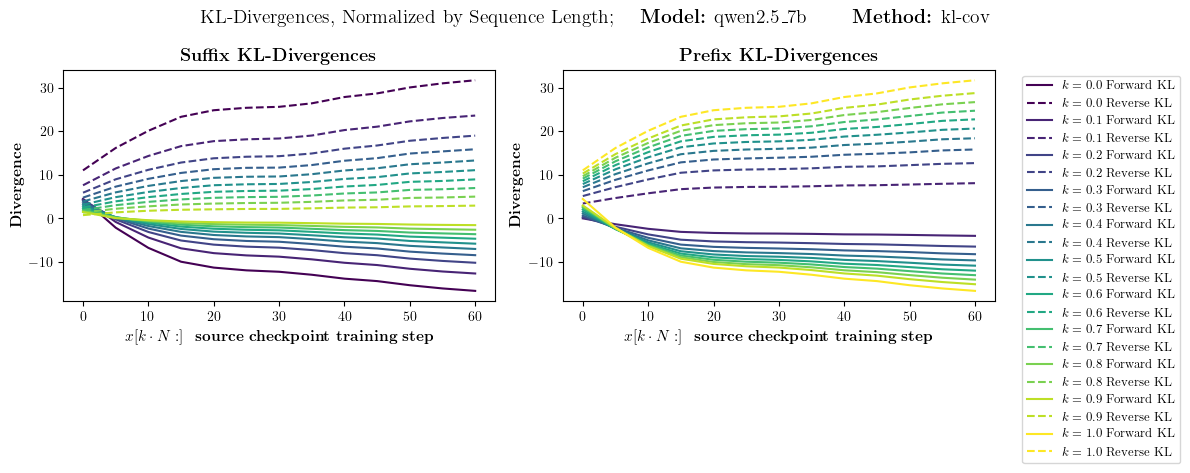

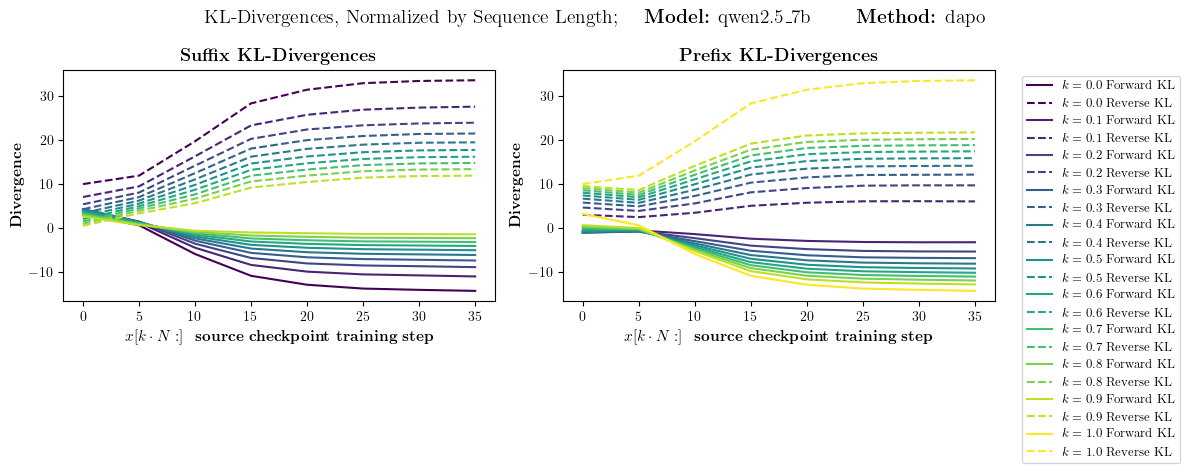

In [25]:
for path in paths:
    experiment_name = path.split('/')[-2]
    method = experiment_name.split('__')[-1]
    df = kls[method]
    plot_kl_prefix_suffix(experiment_name=experiment_name, df=df)